# Customer Churn Prediction using Machine Learning

This project focuses on predicting customer churn using machine learning techniques. The workflow includes data preprocessing, exploratory data analysis (EDA), visualization, feature engineering, model training, and model evaluation.

The objective of this project is to analyze customer behavior patterns and identify factors that contribute to customer churn. Various machine learning techniques were implemented to build predictive models and gain business insights from the dataset.

## Importing Required Libraries

In this step, essential Python libraries are imported for data analysis, visualization, and machine learning operations. Pandas and NumPy are used for data manipulation, while Matplotlib and Seaborn are used for creating visualizations and exploratory data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

The customer churn dataset is loaded into the notebook using the Pandas library. This dataset contains customer demographic details, subscribed services, billing information, and churn status, which will be used for analysis and machine learning model development.

In [27]:
df = pd.read_csv('/content/customer_churn_data.csv')

## Dataset Understanding

This section helps understand the structure of the dataset including rows, columns, feature names, datatypes, and dataset consistency.

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


In [28]:
df.shape

(5880, 21)

In [29]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   object 
 1   gender            5880 non-null   object 
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   object 
 4   Dependents        5880 non-null   object 
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   object 
 7   MultipleLines     5880 non-null   object 
 8   InternetService   5880 non-null   object 
 9   OnlineSecurity    5880 non-null   object 
 10  OnlineBackup      5880 non-null   object 
 11  DeviceProtection  5880 non-null   object 
 12  TechSupport       5880 non-null   object 
 13  StreamingTV       5880 non-null   object 
 14  StreamingMovies   5880 non-null   object 
 15  Contract          5880 non-null   object 
 16  PaperlessBilling  5880 non-null   object 


## Missing Value Analysis

This step checks whether the dataset contains any missing or null values before preprocessing and model training.

In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Data Cleaning and Preprocessing

Data preprocessing techniques are applied to clean the dataset, handle datatypes, and prepare the data for machine learning algorithms.

In [9]:
df.drop('customerID', axis=1, inplace=True)

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df.dropna(inplace=True)

## Exploratory Data Analysis and Visualization

Data visualization techniques are used to analyze customer behavior patterns and identify factors influencing customer churn.

### Churn Distribution Analysis

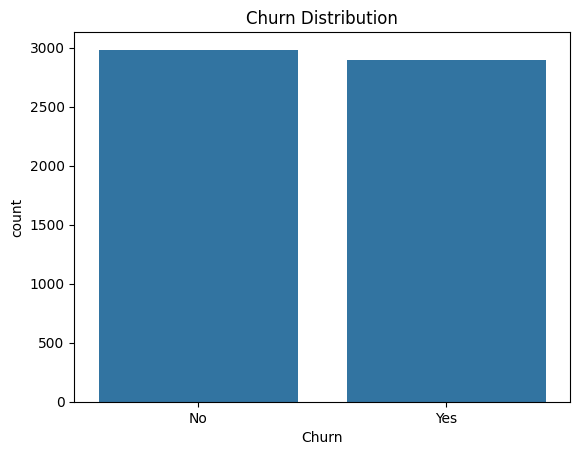

In [12]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

### Gender vs Churn Analysis

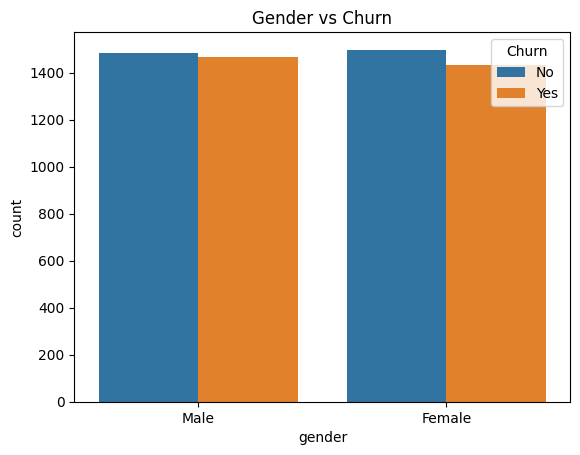

In [13]:
sns.countplot(x='gender', hue='Churn', data=df)
plt.title('Gender vs Churn')
plt.show()

### Contract Type Analysis

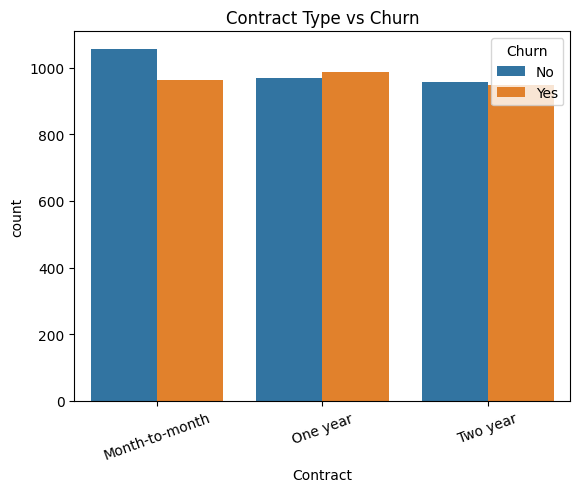

In [14]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.xticks(rotation=20)
plt.show()

### Monthly Charges Distribution

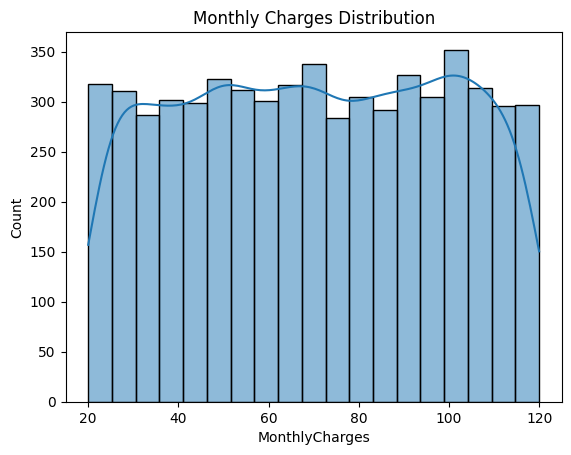

In [15]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title('Monthly Charges Distribution')
plt.show()

## Feature Engineering and Encoding

Categorical variables are converted into numerical format using encoding techniques to prepare the dataset for machine learning models.

In [16]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [17]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [18]:
X = pd.get_dummies(X, drop_first=True)

## Splitting Dataset into Training and Testing Sets

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

Feature scaling is applied to normalize numerical values and improve the performance of machine learning algorithms such as Logistic Regression.

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

Logistic Regression is implemented as a baseline classification algorithm for customer churn prediction.

In [23]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

In [24]:
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [25]:
lr_pred = lr_model.predict(X_test_scaled)

In [26]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.4744897959183674


## Model Evaluation

Evaluation metrics such as accuracy score, classification report, and confusion matrix are used to analyze the performance of the machine learning model.

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.48      0.60      0.53       584
           1       0.47      0.35      0.40       592

    accuracy                           0.47      1176
   macro avg       0.47      0.48      0.47      1176
weighted avg       0.47      0.47      0.47      1176



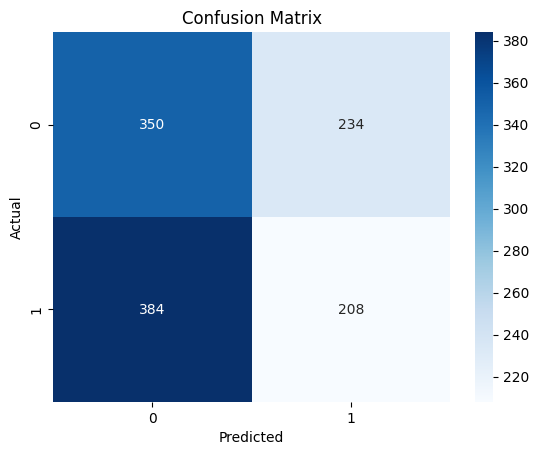

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Random Forest Classifier

Random Forest is implemented as an ensemble machine learning algorithm to improve prediction performance and analyze feature importance.

In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf_model = RandomForestClassifier(random_state=42)

In [35]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [36]:
rf_pred = rf_model.predict(X_test)

In [37]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.49744897959183676


## Feature Importance Analysis

Feature importance analysis helps identify the most influential customer attributes affecting churn prediction.

In [38]:
importance = rf_model.feature_importances_
features = X.columns

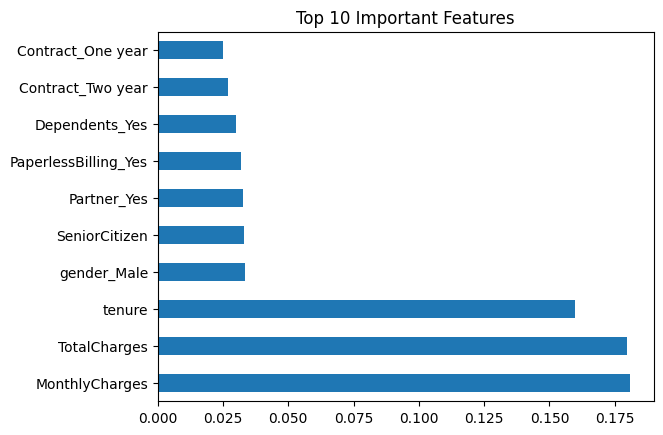

In [39]:
feature_importance = pd.Series(importance, index=features)

feature_importance.nlargest(10).plot(kind='barh')

plt.title('Top 10 Important Features')

plt.show()

## Conclusion

This project successfully implemented an end-to-end machine learning workflow for customer churn prediction. The project included data preprocessing, exploratory data analysis, visualization, feature engineering, model training, and evaluation.

Machine learning models such as Logistic Regression and Random Forest were used to analyze customer behavior and predict churn patterns. The project provided practical understanding of supervised learning, preprocessing techniques, feature engineering, and business-oriented data analysis.
